In [1]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

import sys
for path in sys.path:
    print(path)
    
#print(os.getcwd())
sys.path.append('C:/Users/Tobias/Lena/neurolib')

C:\Users\Tobias\Lena\neurolib
C:\Users\Tobias\anaconda3\python38.zip
C:\Users\Tobias\anaconda3\DLLs
C:\Users\Tobias\anaconda3\lib
C:\Users\Tobias\anaconda3

C:\Users\Tobias\anaconda3\lib\site-packages
C:\Users\Tobias\anaconda3\lib\site-packages\win32
C:\Users\Tobias\anaconda3\lib\site-packages\win32\lib
C:\Users\Tobias\anaconda3\lib\site-packages\Pythonwin
C:\Users\Tobias\anaconda3\lib\site-packages\IPython\extensions
C:\Users\Tobias\.ipython


In [2]:
from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.getcwd()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def step_control(maxI_ = 1.):
    control_ = aln.getZeroControl()
    for i_time in range(control_.shape[2]):
        if ( float(i_time/control_.shape[2]) < 0.1):
            control_[:,:,i_time] = - maxI_
        elif ( float(i_time/control_.shape[2]) > 0.5 and float(i_time/control_.shape[2]) < 0.6 ):
            control_[:,:,i_time] = maxI_
    return control_

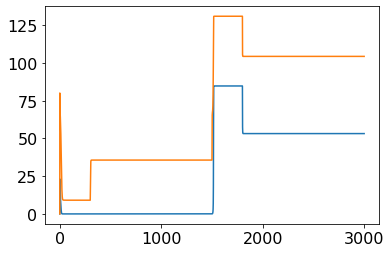

[[9.9409e-03 3.5642e+01]
 [5.3253e+01 1.0443e+02]]


In [4]:
aln = ALNModel()

aln.params['duration'] = 3000.

control0 = aln.getZeroControl()
target = aln.getZeroTarget()
control0 = step_control(maxI_ = 1.)

aln.params.ext_exc_current = 2.3
aln.params.ext_inh_current = 2.5

# NO ADAPTATION => else no bistability
aln.params.IA_init = np.array([0.])
aln.params.a = 0.
aln.params.b = 0.

# no noise
aln.params.sigma_ou = 0.

# no delay
aln.params.signalV = 0.
aln.params.de = 0.
aln.params.di = 0.

state = aln.getZeroState()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

output = aln.output_vars

for i in range(len(output)):
    state[:,i,:] = aln[output[i]][:,:]
    
steady_rates = np.zeros((2, 2))
steady_rates[0,0] = np.mean(state[0,0,3000:15000]) # low state exc
steady_rates[0,1] = np.mean(state[0,1,3000:15000]) # low state inh
steady_rates[1,0] = np.mean(state[0,0,19500:]) # high state exc
steady_rates[1,1] = np.mean(state[0,1,19500:]) #high state inh

print(steady_rates)

state_vars = aln.state_vars
init_vars = aln.init_vars

high_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        high_state_vars[i] = aln.state[state_vars[i]][0]
    else:
        high_state_vars[i] = aln.state[state_vars[i]][0,-2]

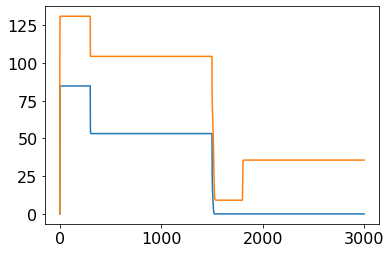

In [5]:
aln.params['duration'] = 3000.
control0 = step_control(maxI_ = -1.)
aln.run(control = control0)
plt.plot(aln.t, aln.rates_exc[0,:])
plt.plot(aln.t, aln.rates_inh[0,:])
plt.show()

low_state_vars = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        low_state_vars[i] = aln.state[state_vars[i]][0] * 0.99
    else:
        low_state_vars[i] = aln.state[state_vars[i]][0,-2] * 0.99  

In [6]:
tol = 1e-12
incl_step = int(1. + aln.params.duration/aln.params.dt)
start_step = 10.
test_step = 1e-6

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

In [7]:
def setinitvars(vars):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = vars[sv]
                else:
                    aln.params[init_vars[iv]][0] = vars[sv]

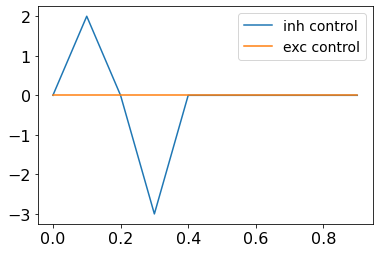

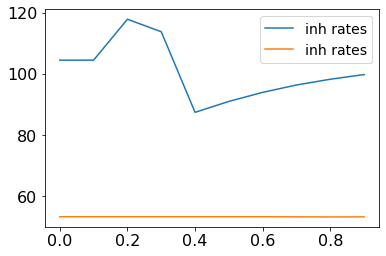

In [8]:
dur = 0.9
dur_pre = 0.5
dur_post = 0.5
aln.params.duration = dur

# no delay
aln.params.signalV = 0.
aln.params.de = 0.3
aln.params.di = 0.2

setinitvars(high_state_vars)

control0 = aln.getZeroControl()

#control0[:,0,2] += 1.
#control0[:,0,3] -= 2.
#control0[:,0,4] -= 3.
#control0[:,0,5] += 3.

control0[:,1,1] += 2.
control0[:,1,3] -= 3.

aln.run(control = control0)


plt.plot(aln.t, control0[0,1,:], label="inh control")
plt.plot(aln.t, control0[0,0,:], label="exc control")
plt.legend()
plt.show()

plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.plot(aln.t, aln.rates_exc[0,:], label="inh rates")
plt.legend()
plt.show()

# set high state rates as target
target = aln.getZeroTarget()
target[:,0,:] = aln.rates_exc[0,:]
target[:,1,:] = aln.rates_inh[0,:]

set cost params
RUN  0 , total integrated cost =  0.00032092430016905264
test control change smaller than tolerance, return zero step
too small start step, increase to  640.0
too small start step, increase to  640.0
continue with start steps  10.0 640.0 10.0 640.0
RUN  1 , total integrated cost =  5.269240225012654e-05
test control change smaller than tolerance, return zero step
too small start step, increase to  40960.0
too small start step, increase to  40960.0
continue with start steps  10.0 40960.0 10.0 40960.0
RUN  2 , total integrated cost =  8.87781412070848e-06
test control change smaller than tolerance, return zero step
continue with start steps  10.0 640.0 10.0 640.0
RUN  3 , total integrated cost =  3.6081534214352766e-06
test control change smaller than tolerance, return zero step
too small start step, increase to  40960.0
too small start step, increase to  40960.0
continue with start steps  10.0 40960.0 10.0 40960.0
RUN  4 , total integrated cost =  3.2919333023273783e-06


ERROR:root:Problem in initial value trasfer


 40960.0
continue with start steps  10.0 40960.0 10.0 40960.0
RUN  100 , total integrated cost =  4.744919735776247e-12
Improved over  100  iterations by  99.99999852148319  percent.
Problem in initial value trasfer:  Vmean_exc -56.70423076132687 -56.704263996040424
grad =  [[[ 0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00
    0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00  0.0000e+00]
  [ 0.0000e+00  4.2452e-08 -4.7435e-08  6.9773e-09 -1.3402e-12
    2.9707e-13  1.5966e-13  1.9532e-13  0.0000e+00  0.0000e+00]]]


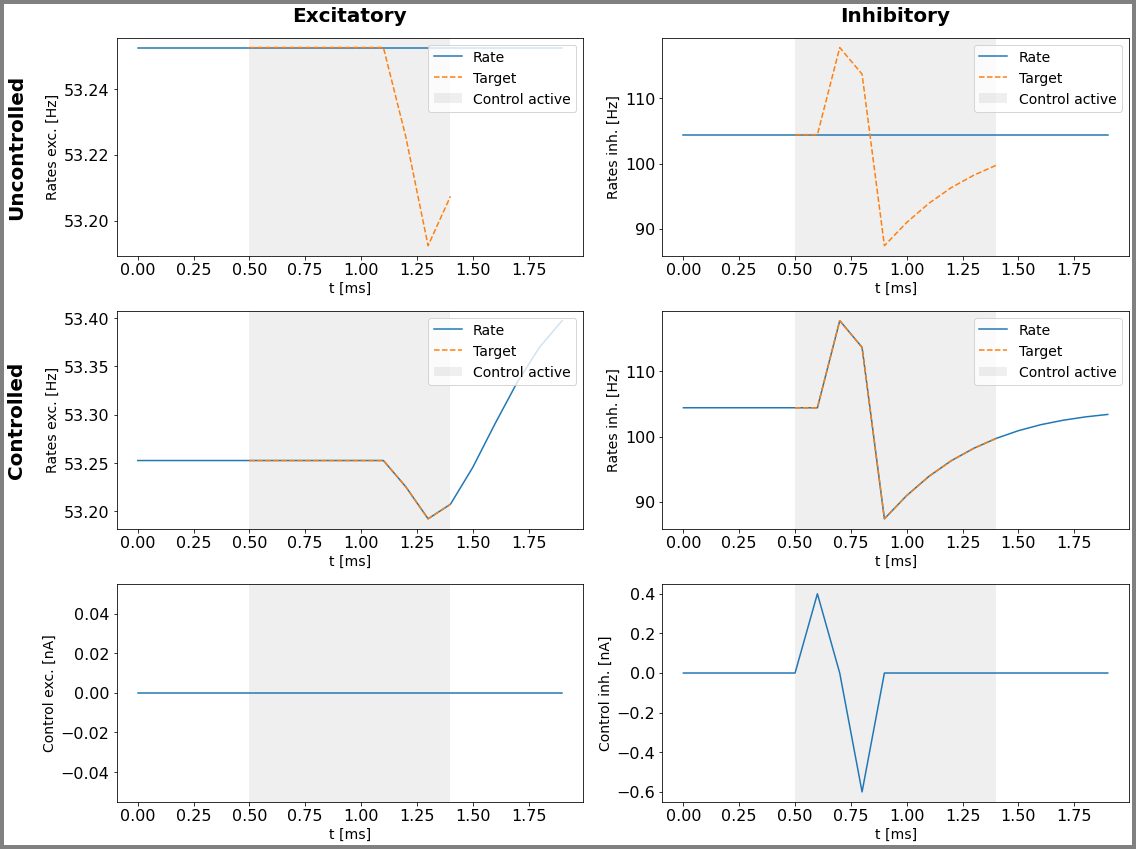

In [9]:
cost.setParams(1.0, 0., 0.0)
max_cntrl = 100. * 5.

setinitvars(high_state_vars)
max_it = 100
alg = "A1"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()
#control1 = bestControlA[:,:,5:15]

bestControlA, bestStateA, costA, runtimeA, grad = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, variables_ = [0])

plotFunc.plot_control(aln, bestControlA, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))

print("grad = ", grad)

for i in range(1, len(costA)):
    if costA[i-1] < costA[i]:
        print("ERROR ---------------- in index ", i)

In [ ]:
setinitvars(high_state_vars)
max_it = 10
alg = "A2"
case = "A"

aln.params.duration = dur
control0 = aln.getZeroControl()
control1 = bestControlA2[:,:,5:15]

bestControlA2, bestStateA2, costA2, runtimeA2 = aln.A2(control1, target, max_iteration_ = max_it,
                tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
                max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

plotFunc.plot_control(aln, bestControlA2, dur, dur_pre, dur_post, high_state_vars, target,
                      path, filename_ = str('p1_e1_s1_u1nA_LowHigh_' + case + "_" + alg))


for i in range(1, len(costA2)):
    if costA2[i-1] < costA2[i]:
        print("ERROR ---------------- in index ", i)

In [ ]:
diff = bestControlA2 - bestControlA
diff_state = bestStateA2 - bestStateA

#diff[:,:,0] = 0
#diff[:,:,-1] = 0

sparsitygradientinh = np.array( [ 0.,9.49932197e-02,3.44809490e+00,-3.02161508e-02,-5.29884978e+00,
    -1.51166411e-01,-6.67096985e-03,-6.46825813e-05,-2.28743628e-04,0. ] )
adjointgradientinh = np.array( [ 0.,-9.49924781e-02,-3.44809399e+00,3.02175014e-02,5.29885118e+00,
     1.51167334e-01,6.67158491e-03,6.52247394e-05,2.28994155e-04,0. ] )

print(diff)

t = np.arange(0,dur+0.1, 0.1)

plt.plot(t, diff[0,0,5:15], label="difference in exc control")
plt.plot(t, 1e1 *diff[0,1,5:15], label="difference in inh control")
#plt.plot(t, bestControlA[0,1,5:15], label="inh control")
#plt.plot(t, - 1e0 * grad[0,0,:], label="grad exc")
#plt.plot(t, - 1e0 * grad[0,1,:], label="grad inh")
#plt.plot(t, - 1e0 *sparsitygradientinh, label = "sparsity grad")
#plt.plot(t, - 1e0 * adjointgradientinh, label = "adjoint grad")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()

plt.plot(t, diff_state[0,0,5:15], label="difference in exc rates")
plt.plot(t, diff_state[0,1,5:15], label="difference in inh rates")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid()
plt.show()